# Quantisieren
Es gibt zwei Ansätze, ein Modell zu quantisieren: nach dem Training oder während des Trainings. Dieses Notebook zeigt beide Varianten am Beispiel von ResNet50.


### Datensatz
Zum Training benötigt man einen Datensatz. Da der originale ImageNet-Datensatz mit etwa 140 GB sehr groß ist, wird zunächst ein kleinerer Datensatz (ca. 16 GB) verwendet. Dieser enthält weniger Bilder und nur 100 Klassen. Der Code sollte den Datensatz entsprechend unterstützen.

In [1]:
"""
import kagglehub
import shutil
import os

# Download latest version
path = kagglehub.dataset_download("ambityga/imagenet100")

print("Path to dataset files:", path)

target = "../data/imagenet100/versions/8"
os.makedirs(os.path.dirname(target), exist_ok=True)

shutil.copytree(path, target, dirs_exist_ok=True)
"""
ROOT = "../data/imagenet100/versions/8"


### Imports
Das Paket muss mit pip install -e . installiert werden (im Hauptverzeichnis), falls dies noch nicht gemacht wurde. #!pip install -e . kann bei Bedarf auskommentiert werden.

In [13]:
from maco_package.quantization import *
from maco_package.utils import *
from maco_package.data import *
from maco_package.visualization import *
from maco_package.xai import *

## Vortrainiertes Modell laden

Zuerst wird ein vortrainiertes, quantisierbares ResNet50-Modell als Basis geladen. Da das Modell bereits teilweise auf ähnlichen Daten trainiert wurde, liefert es bereits sinnvolle Ergebnisse. Da der neue Datensatz jedoch weniger Klassen enthält, muss die letzte Schicht des Modells angepasst und anschließend fine-tuned werden.



Label: snail


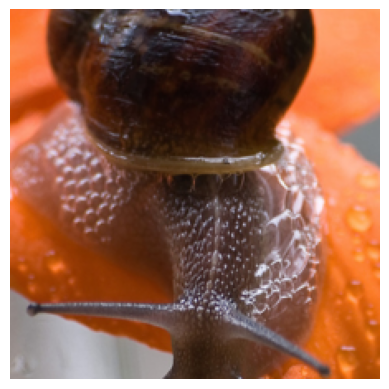

In [14]:
modelfp32 = load_resnet("qresnet50", pretrained=True)
#ROOT = "/home/neli/.cache/kagglehub/datasets/ambityga/imagenet100/versions/8"
train_dataset, val_dataset, class_to_idx = build_datasets(ROOT)
NUM_CLASSES = len(class_to_idx)
synset_to_name = load_class_names(ROOT)

img = show_random_sample(train_dataset, class_to_idx, synset_to_name,return_sample=True)

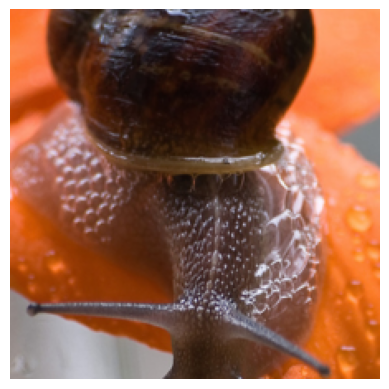


Top-5 predictions:
snail: 60.92%
slug: 1.91%
orange: 0.23%
conch: 0.15%
soup bowl: 0.09%


In [15]:
cats = models.ResNet50_Weights.DEFAULT.meta["categories"]
ShowTop5(modelfp32, img , cats)

In [6]:
modelfp32_ft = finetuneModel(
    modelfp32,
    train_dataset,
    val_dataset,
    num_classes=len(class_to_idx),
    epochs=10,
    full_finetune=False
)

[Epoch 1] loss=0.6017 acc=87.62%


[Epoch 2] loss=0.2318 acc=87.60%


[Epoch 3] loss=0.1863 acc=87.38%


[Epoch 4] loss=0.1609 acc=87.60%


[Epoch 5] loss=0.1419 acc=86.98%


[Epoch 6] loss=0.1295 acc=87.16%


[Epoch 7] loss=0.1180 acc=86.62%


[Epoch 8] loss=0.1103 acc=86.72%


[Epoch 9] loss=0.1037 acc=86.76%


[Epoch 10] loss=0.0978 acc=86.70%


Modell zwischenspeichern 

In [25]:
import torch
import os

save_path = "../saved_models/resnet50_finetuned.pth"
os.makedirs(os.path.dirname(save_path), exist_ok=True)

torch.save(modelfp32_ft.state_dict(), save_path)

In [16]:
state = torch.load("../saved_models/resnet50_finetuned.pth")

from torchvision.models.quantization import resnet50 as qresnet50

modelfp32_ft = qresnet50(quantize=False, weights=None)
modelfp32_ft.fc = torch.nn.Linear(2048, len(class_to_idx))
modelfp32_ft.load_state_dict(state)

<All keys matched successfully>

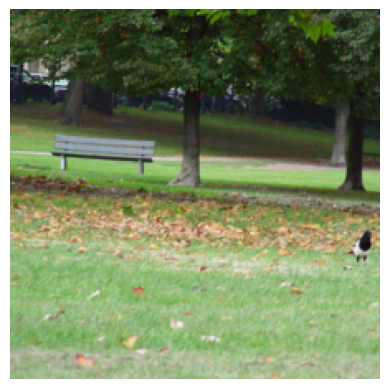


Top-5 predictions:
magpie: 53.52%
sulphur-crested cockatoo, Kakatoe galerita, Cacatua galerita: 27.04%
wallaby, brush kangaroo: 8.59%
crane: 2.80%
white stork, Ciconia ciconia: 2.49%


In [6]:
idx_to_name = {
    idx: synset_to_name[synset]
    for synset, idx in class_to_idx.items()
}

ShowTop5(modelfp32_ft, img , idx_to_name)

## Post-Training Quantization (PTQ)

Um ein Modell nach dem Training zu quantisieren, lässt man zuerst ein paar echte Batches durch das FP32-Modell laufen und erzeugt dann ein INT8-PTQ-Modell, indem genau diese beobachteten Werte benutzt werden, um die passenden INT8-Bereiche festzulegen und das FP32-Modell automatisch in seine INT8-Version umzubauen


In [8]:
train_loader, val_loader, class_to_idx = build_loaders(ROOT, batch_size=64)
calib = get_calibration_batch(train_loader, num_batches=3)
ptqmodel = QuantizePTQ(modelfp32_ft, calibration_input=calib)

In [10]:
import torch
import os

save_path = "../saved_models/resnet50_ptq.pth"
os.makedirs(os.path.dirname(save_path), exist_ok=True)

torch.save(ptqmodel.state_dict(), save_path)

## Quantization-Aware Training (QAT)

Um ein Modell quantisierungsbewusst zu trainieren, fügt man während des Trainings künstliche Quantisierungs- und Dequantisierungs-Operationen ein, sodass das FP32-Modell bereits im Training lernt, mit den späteren INT8-Einschränkungen umzugehen, und nach dem Training direkt als INT8-Modell exportiert werden kann. Daraus erhält man zwei Modelle: das künstlich quantisierte Trainingsmodell, das nur während des QAT genutzt wird, und das echte quantisierte INT8-Modell, das nach dem Training exportiert und ausgeführt wird.

In [7]:
qat_model, int8_model = trainQAT(
    modelfp32_ft,
    train_dataset,
    val_dataset,
    epochs=5
)

/home/neli/.local/share/mamba/envs/Master/lib/python3.12/site-packages/torch/ao/quantization/observer.py:246: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(
                                                                                                                

[Epoch 1/5] Loss=0.1952 | ValAcc=84.84%


[Epoch 2/5] Loss=0.1659 | ValAcc=85.14%


[Epoch 3/5] Loss=0.1733 | ValAcc=82.98%


[Epoch 4/5] Loss=0.1871 | ValAcc=84.26%


[Epoch 5/5] Loss=0.1611 | ValAcc=85.44%


(QuantizableResNet(
   (conv1): ConvReLU2d(
     3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3)
     (weight_fake_quant): FusedMovingAvgObsFakeQuantize(
       fake_quant_enabled=tensor([1]), observer_enabled=tensor([1]), scale=tensor([0.0227, 0.0086, 0.0049, 0.0054, 0.0206, 0.0209, 0.0161, 0.0087, 0.0029,
               0.0198, 0.0131, 0.0189, 0.0031, 0.0032, 0.0173, 0.0063, 0.0113, 0.0090,
               0.0139, 0.0034, 0.0071, 0.0146, 0.0047, 0.0072, 0.0055, 0.0072, 0.0052,
               0.0104, 0.0346, 0.0024, 0.0169, 0.0136, 0.0102, 0.0067, 0.0136, 0.0081,
               0.0134, 0.0200, 0.0131, 0.0055, 0.0079, 0.0085, 0.0181, 0.0117, 0.0173,
               0.0133, 0.0151, 0.0133, 0.0236, 0.0152, 0.0252, 0.0464, 0.0024, 0.0183,
               0.0034, 0.0212, 0.0083, 0.0059, 0.0044, 0.0040, 0.0138, 0.0075, 0.0395,
               0.0147]), zero_point=tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
               0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [19]:
save_path = "../saved_models/resnet50_qatfake.pth"
os.makedirs(os.path.dirname(save_path), exist_ok=True)

torch.save(model_qat.state_dict(), save_path)

In [18]:
save_path = "../saved_models/resnet50_qat_int8.pth"
os.makedirs(os.path.dirname(save_path), exist_ok=True)

torch.save(model_int8.state_dict(), save_path)